# Trial Activation Analysis

In [1]:
# Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Cleaning & Exploration
- Proper deduplication; timestamp parsing; derived fields; documented quality checks; meaningful EDA visualisations.

In [2]:
# Load data
df_trial = pd.read_csv(
    "G:/Other computers/Laptop - GoogleDrive/data analytics/projects/trial activation _ splendor analytics data challenge/dataset/trial_events.csv"
)

# View first 5 rows
df_trial.head()

,ORGANIZATION_ID,ACTIVITY_NAME,TIMESTAMP,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00.000,False,NaN,2024-03-27 10:11:39.000,2024-04-26 10:11:39.000


In [3]:
# Check shape
df_trial.shape

(170526, 7)

In [4]:
# Check nulls
df_trial.isnull().sum()

ORGANIZATION_ID         0
ACTIVITY_NAME           0
TIMESTAMP               0
CONVERTED               0
CONVERTED_AT       136291
TRIAL_START             0
TRIAL_END               0
dtype: int64

In [5]:
# Check data types
df_trial.dtypes

ORGANIZATION_ID    object
ACTIVITY_NAME      object
TIMESTAMP          object
CONVERTED            bool
CONVERTED_AT       object
TRIAL_START        object
TRIAL_END          object
dtype: object

### Parse data types to datetime for;
- TIMESTAMP
- CONVERTED_AT
- TRIAL_START
- TRIAL_END 

In [6]:
timestamp_cols = ['TIMESTAMP', 'CONVERTED_AT', 'TRIAL_START', 'TRIAL_END']

for col in timestamp_cols:
    df_trial[col] = pd.to_datetime(df_trial[col])

df_trial.dtypes

ORGANIZATION_ID            object
ACTIVITY_NAME              object
TIMESTAMP          datetime64[ns]
CONVERTED                    bool
CONVERTED_AT       datetime64[ns]
TRIAL_START        datetime64[ns]
TRIAL_END          datetime64[ns]
dtype: object

### Trim leading/trailing spaces from text columns

In [7]:
text_cols = ['ORGANIZATION_ID', 'ACTIVITY_NAME']

for col in text_cols:
    df_trial[col] = df_trial[col].astype(str).str.strip()

### Duplicates Check

In [8]:
df_trial.duplicated().any()

np.True_

In [9]:
df_trial[df_trial.duplicated()].head()

,ORGANIZATION_ID,ACTIVITY_NAME,TIMESTAMP,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END
153,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-17 22:58:40,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
155,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-17 22:58:41,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
156,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-04-17 22:58:41,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
195,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.AssignmentChanged,2024-04-19 17:52:03,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
196,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.AssignmentChanged,2024-04-19 17:52:03,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39


In [10]:
df_trial.duplicated().sum()

np.int64(67631)

#### Drop Duplicates
- 67,631 rows affected

In [11]:
df_trial = df_trial.drop_duplicates()

#### Unique entries after deduplication = 102,895

In [12]:
df_trial.shape

(102895, 7)

### Data Quality Checks
- Check unique values in '**ACTIVITY_NAME**'

In [13]:
sorted(df_trial['ACTIVITY_NAME'].unique())

['Absence.Request.Approved',
 'Absence.Request.Created',
 'Absence.Request.Rejected',
 'Break.Activate.Finished',
 'Break.Activate.Started',
 'Communication.Message.Created',
 'Integration.Xero.PayrollExport.Synced',
 'Mobile.Schedule.Loaded',
 'PunchClock.Entry.Edited',
 'PunchClock.PunchedIn',
 'PunchClock.PunchedOut',
 'PunchClockEndNote.Add.Completed',
 'PunchClockStartNote.Add.Completed',
 'Revenue.Budgets.Created',
 'Scheduling.Availability.Set',
 'Scheduling.OpenShiftRequest.Approved',
 'Scheduling.OpenShiftRequest.Created',
 'Scheduling.Shift.Approved',
 'Scheduling.Shift.AssignmentChanged',
 'Scheduling.Shift.Created',
 'Scheduling.ShiftHandover.Accepted',
 'Scheduling.ShiftHandover.Created',
 'Scheduling.ShiftSwap.Accepted',
 'Scheduling.ShiftSwap.Created',
 'Scheduling.Template.ApplyModal.Applied',
 'Shift.View.Opened',
 'ShiftDetails.View.Opened',
 'Timesheets.BulkApprove.Confirmed']

In [14]:
df_trial['ACTIVITY_NAME'].nunique()

28

### Count Distinct ORGANIZATION_ID

In [15]:
df_trial['ORGANIZATION_ID'].nunique()

966

#### Trial Length Validation
- Exactly 30 days for each organization

In [16]:
trial_length = (
    df_trial.groupby('ORGANIZATION_ID')
      .agg(
          trial_start=('TRIAL_START', 'first'),
          trial_end=('TRIAL_END', 'first')
      )
      .assign(trial_length_days=lambda x: (x['trial_end'] - x['trial_start']).dt.days)
      .drop(columns=['trial_start', 'trial_end'])
      .reset_index()
)

# Summary stats
trial_length.describe().T

,count,mean,std,min,25%,50%,75%,max
trial_length_days,966.0,30.0,0.0,30.0,30.0,30.0,30.0,30.0


### Validate unique values per ORGANIZATION_ID for selected fields;
- CONVERTED
- CONVERTED_AT
- TRIAL_START
- TRIAL_END

In [17]:
# Count unique values per organization for each column
validation_counts = (
    df_trial
    .groupby('ORGANIZATION_ID')
    .agg({
        'CONVERTED': 'nunique',
        'CONVERTED_AT': 'nunique',
        'TRIAL_START': 'nunique',
        'TRIAL_END': 'nunique'
    })
)

# Show the maximum unique count per column
validation_summary = validation_counts.max()

validation_summary

CONVERTED       1
CONVERTED_AT    1
TRIAL_START     1
TRIAL_END       1
dtype: int64

### Aggregate data by ORGANIZATION_ID
- **DataFrame**: df_organization

In [18]:
# Create one row per organization, keeping only columns that are unique per org
df_organization = (
    df_trial
    .groupby('ORGANIZATION_ID', as_index=False)
    .agg({
        'CONVERTED': 'first',    # same value for all rows per org
        'CONVERTED_AT': 'first', # timestamp corresponding to CONVERTED
        'TRIAL_START': 'first',  # unique start date per org
        'TRIAL_END': 'first'     # unique end date per org
    })
)

df_organization.head()

,ORGANIZATION_ID,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END
0,0040dd9ab132b92d5d04bc3acf14d2e2,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39
1,00456fd86311b6095ad05f7e31758f0d,False,NaT,2024-01-11 13:44:36,2024-02-10 13:44:36
2,007d48a2bc006e6eac0348c788d26dfd,False,NaT,2024-03-16 22:58:07,2024-04-15 22:58:07
3,00d6461845d0042b929379c263e9edef,False,NaT,2024-03-05 02:57:05,2024-04-04 02:57:05
4,00d812389a3cffdbf014ba194cbe922e,False,NaT,2024-03-13 22:13:10,2024-04-12 22:13:10


In [19]:
df_organization.shape

(966, 5)

## Derived Fields (for insights into conversion)

#### Field 1 - Conversion Speed
- **`days_to_convert`**

#### Field 2 - Monthly Cohort
- **`trial_start_month`**


## Derived Fields (for conversion drivers)

#### Fields 3 - Engagement Depth
- **`total_events`**: Total amount of activity user performed

#### Field 4 - Breadth of Usage
- **`unique_activity_count`**: Variety of features, activity, or modules a user interacts with

#### Field 5 - Active Days Threshold
- **`active_days`**: Number of distinct active days

#### Field 6 (Multiple fields based on ACTIVITY_NAME)
- Measures **Activity Usage Breadth**
- **Flag** Organisation used Activity at least once **(1/0)**

[**Hint**: Create **Pivot_table** (one row per ORGANIZATION_ID, one field per ACTIVITY_NAME) with **Values = (1/0)**]

#### Field 7 (Multiple fields based on ACTIVITY_NAME)
- Measures **Activity Usage Depth (Volume)**
- **Count**: **Number of times** Organisation used Activity

[**Hint**: Create **Pivot_table** (one row per ORGANIZATION_ID, one field per ACTIVITY_NAME) with **Values = count**]

### Field 1 - Conversion Speed
### **`days_to_convert`**

In [20]:
# Calculate days from trial start to conversion (store as whole numbers)
df_organization['days_to_convert'] = (
    (df_organization['CONVERTED_AT'] - df_organization['TRIAL_START'])
    .dt.days
    .astype('Int64')   # keeps whole numbers and allows missing values
)

### Field 2 - Monthly Cohort
### **`trial_start_month`**

In [21]:
# Extract month from trial start date (store as whole numbers)
df_organization['trial_start_month'] = (
    df_organization['TRIAL_START']
    .dt.month
    .astype('Int64')   # ensures whole numbers without .0
)

### Field 3 - Engagement Depth
### **`total_events`**

In [22]:
# total number of activities per organization (computed from df_trial and merged into df_organization)
total_events = (
    df_trial
    .groupby('ORGANIZATION_ID')
    .size()
    .reset_index(name='total_events')
)

df_organization = df_organization.merge(total_events, on='ORGANIZATION_ID', how='left')
df_organization['total_events'] = df_organization['total_events'].fillna(0).astype('Int64')

### Field 4 - Breadth of Usage
### **`unique_activity_count`**

In [23]:
# Number of distinct ACTIVITY_NAME per organization (computed from df_trial and merged into df_organization)
unique_activity_count = (
    df_trial
    .groupby('ORGANIZATION_ID')['ACTIVITY_NAME']
    .nunique()
    .reset_index(name='unique_activity_count')
)

df_organization = df_organization.merge(unique_activity_count, on='ORGANIZATION_ID', how='left')
df_organization['unique_activity_count'] = df_organization['unique_activity_count'].fillna(0).astype('Int64')

### Field 5 - Active Days Threshold
### **`active_days`**

In [24]:
# Number of unique days with any activity (computed from df_trial and merged into df_organization)
active_days = (
    df_trial
    .assign(activity_date=df_trial['TIMESTAMP'].dt.date)
    .groupby('ORGANIZATION_ID')['activity_date']
    .nunique()
    .reset_index(name='active_days')
)

df_organization = df_organization.merge(active_days, on='ORGANIZATION_ID', how='left')
df_organization['active_days'] = df_organization['active_days'].fillna(0).astype('Int64')

### Field 6 (Multiple fields based on ACTIVITY_NAME)
- Measures **Activity Usage Breadth**
- **Flag** Organisation used Activity at least once **(1/0)**

**DataFrame**: **`df_activity_pivot_flag`**

In [25]:
df_activity_pivot_flag = (
    df_trial
    .assign(flag=1)
    .pivot_table(
        index='ORGANIZATION_ID',
        columns='ACTIVITY_NAME',
        values='flag',
        aggfunc='max',
        fill_value=0
    )
    .reset_index()
)

df_activity_pivot_flag.columns.name = None

In [26]:
df_activity_pivot_flag.shape

(966, 29)

In [27]:
df_activity_pivot_flag.head()

,ORGANIZATION_ID,Absence.Request.Approved,Absence.Request.Created,Absence.Request.Rejected,Break.Activate.Finished,Break.Activate.Started,Communication.Message.Created,Integration.Xero.PayrollExport.Synced,Mobile.Schedule.Loaded,PunchClock.Entry.Edited,...,Scheduling.Shift.AssignmentChanged,Scheduling.Shift.Created,Scheduling.ShiftHandover.Accepted,Scheduling.ShiftHandover.Created,Scheduling.ShiftSwap.Accepted,Scheduling.ShiftSwap.Created,Scheduling.Template.ApplyModal.Applied,Shift.View.Opened,ShiftDetails.View.Opened,Timesheets.BulkApprove.Confirmed
0,0040dd9ab132b92d5d04bc3acf14d2e2,1,1,1,0,0,1,0,1,1,...,1,1,0,0,0,0,1,0,1,0
1,00456fd86311b6095ad05f7e31758f0d,0,0,0,0,0,1,0,1,0,...,1,1,0,0,0,0,0,0,0,0
2,007d48a2bc006e6eac0348c788d26dfd,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,00d6461845d0042b929379c263e9edef,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,00d812389a3cffdbf014ba194cbe922e,0,0,0,0,0,1,0,1,0,...,1,1,0,0,0,0,0,0,0,0


### Merge
- df_activity_pivot_flag; **into**
- df_organization; **as**
- **`df_organization_act_flag`**

In [28]:
# Merge df_org_activity_pivot (activity usage counts) into df_organization
df_organization_act_flag = df_organization.merge(
    df_activity_pivot_flag,
    on='ORGANIZATION_ID',
    how='left'
)

In [29]:
df_organization_act_flag.shape

(966, 38)

In [30]:
df_organization_act_flag.head(3)

,ORGANIZATION_ID,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END,days_to_convert,trial_start_month,total_events,unique_activity_count,active_days,...,Scheduling.Shift.AssignmentChanged,Scheduling.Shift.Created,Scheduling.ShiftHandover.Accepted,Scheduling.ShiftHandover.Created,Scheduling.ShiftSwap.Accepted,Scheduling.ShiftSwap.Created,Scheduling.Template.ApplyModal.Applied,Shift.View.Opened,ShiftDetails.View.Opened,Timesheets.BulkApprove.Confirmed
0,0040dd9ab132b92d5d04bc3acf14d2e2,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,<NA>,3,1004,14,11,...,1,1,0,0,0,0,1,0,1,0
1,00456fd86311b6095ad05f7e31758f0d,False,NaT,2024-01-11 13:44:36,2024-02-10 13:44:36,<NA>,1,6,4,1,...,1,1,0,0,0,0,0,0,0,0
2,007d48a2bc006e6eac0348c788d26dfd,False,NaT,2024-03-16 22:58:07,2024-04-15 22:58:07,<NA>,3,5,2,3,...,0,0,0,0,0,0,0,0,0,0


#### Field 7 (Multiple fields based on ACTIVITY_NAME)
- Measures **Activity Usage Depth (Volume)**
- **Count**: **Number of times** Organisation used Activity

**DataFrame**: **`df_activity_pivot_count`**

In [31]:
# Create activity count pivot table
# Goal: Count how many times each organization used each activity

df_activity_pivot_count = (
    df_trial

    # Group by organization and activity
    .groupby(['ORGANIZATION_ID', 'ACTIVITY_NAME'])

    # Count occurrences
    .size()

    # Convert activity names into columns
    .unstack(fill_value=0)

    # Convert index back to column
    .reset_index()
)

# Remove pivot column grouping label (if present)
df_activity_pivot_count.columns.name = None

# Preview result
df_activity_pivot_count.head()

,ORGANIZATION_ID,Absence.Request.Approved,Absence.Request.Created,Absence.Request.Rejected,Break.Activate.Finished,Break.Activate.Started,Communication.Message.Created,Integration.Xero.PayrollExport.Synced,Mobile.Schedule.Loaded,PunchClock.Entry.Edited,...,Scheduling.Shift.AssignmentChanged,Scheduling.Shift.Created,Scheduling.ShiftHandover.Accepted,Scheduling.ShiftHandover.Created,Scheduling.ShiftSwap.Accepted,Scheduling.ShiftSwap.Created,Scheduling.Template.ApplyModal.Applied,Shift.View.Opened,ShiftDetails.View.Opened,Timesheets.BulkApprove.Confirmed
0,0040dd9ab132b92d5d04bc3acf14d2e2,3,3,1,0,0,9,0,11,1,...,384,576,0,0,0,0,10,0,1,0
1,00456fd86311b6095ad05f7e31758f0d,0,0,0,0,0,1,0,1,0,...,3,1,0,0,0,0,0,0,0,0
2,007d48a2bc006e6eac0348c788d26dfd,0,0,0,0,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
3,00d6461845d0042b929379c263e9edef,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,00d812389a3cffdbf014ba194cbe922e,0,0,0,0,0,1,0,111,0,...,311,157,0,0,0,0,0,0,0,0


### Merge
- df_activity_pivot_count; **into**
- df_organization; **as**
- **`df_organization_act_count`**

In [32]:
# Merge df_org_activity_pivot (activity usage counts) into df_organization
df_organization_act_count = df_organization.merge(
    df_activity_pivot_count,
    on='ORGANIZATION_ID',
    how='left'
)

In [33]:
df_organization_act_count.head(3)

,ORGANIZATION_ID,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END,days_to_convert,trial_start_month,total_events,unique_activity_count,active_days,...,Scheduling.Shift.AssignmentChanged,Scheduling.Shift.Created,Scheduling.ShiftHandover.Accepted,Scheduling.ShiftHandover.Created,Scheduling.ShiftSwap.Accepted,Scheduling.ShiftSwap.Created,Scheduling.Template.ApplyModal.Applied,Shift.View.Opened,ShiftDetails.View.Opened,Timesheets.BulkApprove.Confirmed
0,0040dd9ab132b92d5d04bc3acf14d2e2,False,NaT,2024-03-27 10:11:39,2024-04-26 10:11:39,<NA>,3,1004,14,11,...,384,576,0,0,0,0,10,0,1,0
1,00456fd86311b6095ad05f7e31758f0d,False,NaT,2024-01-11 13:44:36,2024-02-10 13:44:36,<NA>,1,6,4,1,...,3,1,0,0,0,0,0,0,0,0
2,007d48a2bc006e6eac0348c788d26dfd,False,NaT,2024-03-16 22:58:07,2024-04-15 22:58:07,<NA>,3,5,2,3,...,0,0,0,0,0,0,0,0,0,0


## Trial Performance Data Exploration

### Conversion Status

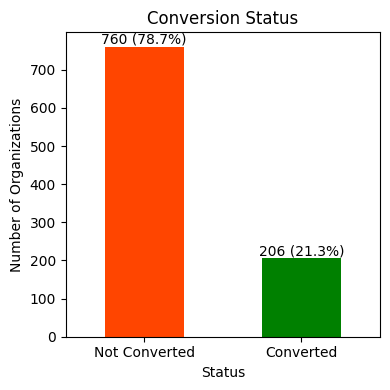

In [34]:
# Count converted vs non-converted
conversion_counts = (
    df_organization['CONVERTED']
    .value_counts()
    .reindex([False, True])  # ensure correct order
)

# Rename labels for readability
conversion_counts.index = ['Not Converted', 'Converted']

# Calculate percentages
total = conversion_counts.sum()
percentages = (conversion_counts / total * 100).round(1)

# Create figure
plt.figure(figsize=(4, 4))

# Plot bar chart with specified colours
ax = conversion_counts.plot(
    kind='bar',
    color=['orangered', 'green']
)

# Make x-axis labels horizontal
plt.xticks(rotation=0)

# Add count and percentage labels
for i, value in enumerate(conversion_counts):
    pct = percentages.iloc[i]  # FIX: use .iloc for position-based indexing

    ax.text(
        i,
        value,
        f'{value} ({pct}%)',
        ha='center',
        va='bottom'
    )

# Titles and labels
plt.title('Conversion Status')
plt.xlabel('Status')
plt.ylabel('Number of Organizations')

plt.tight_layout()
plt.show()

### **`days_to_convert`** Distribution

#### Outcome:
- The distribution of `days_to_convert` appears roughly normal with a slight right skew due to late conversions.
- Most organizations convert around the end of the 30-day trial, with a few late converters.
- This indicates that the bulk of conversion activity occurs near the trial’s end.
- Trial goals or engagement nudges might be most effective if targeted during the middle to later part of the trial.

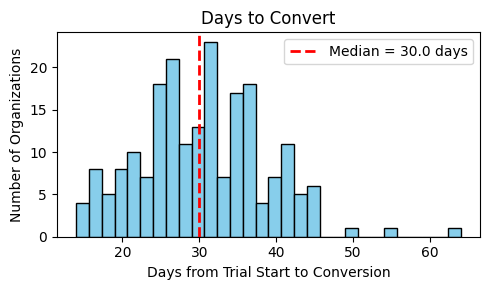

,count,mean,std,min,25%,50%,75%,max
days_to_convert,206.0,30.271845,8.207307,14.0,25.0,30.0,36.0,64.0


In [35]:
# Filter out non-converters (NaN values in days_to_convert)
converted_days = df_organization['days_to_convert'].dropna()

# Calculate median
median_days = converted_days.median()

plt.figure(figsize=(5, 3))

# Histogram
plt.hist(
    converted_days,
    bins=30,
    color='skyblue',
    edgecolor='black'
)

# Add red dashed median line
plt.axvline(
    median_days,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Median = {median_days:.1f} days'
)

plt.title('Days to Convert')
plt.xlabel('Days from Trial Start to Conversion')
plt.ylabel('Number of Organizations')

plt.legend()  # show median label

plt.tight_layout()
plt.show()

# Descriptive stats
df_organization['days_to_convert'].describe().to_frame().T

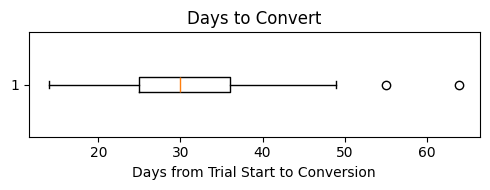

In [36]:
# Descriptive summary of days_to_convert

# Box Plot to visualize spread and outliers
plt.figure(figsize=(5, 2))
plt.boxplot(df_organization['days_to_convert'].dropna(), vert=False)
plt.title('Days to Convert')
plt.xlabel('Days from Trial Start to Conversion')
plt.tight_layout()
plt.show()

### Conversions by day 30 of Trial:

In [37]:
# Total number of converters
total_converters = (
    df_organization_act_count[
        df_organization_act_count['CONVERTED']
    ]
    .shape[0]
)

# Number of converters by Day 30
converted_by_day_30 = (
    df_organization_act_count[
        (df_organization_act_count['CONVERTED']) &
        (df_organization_act_count['days_to_convert'] <= 30)
    ]
    .shape[0]
)

# Percentage of converters by Day 30
pct_converted_by_day_30 = (
    converted_by_day_30 / total_converters
) * 100

# Create output dataframe
conversion_day_30_df = pd.DataFrame({
    'TOTAL_CONVERTERS': [total_converters],
    'CONVERTED_BY_DAY_30': [converted_by_day_30],
    'PCT_CONVERTED_BY_DAY_30': [
        round(pct_converted_by_day_30, 2)
    ]
})

conversion_day_30_df

,TOTAL_CONVERTERS,CONVERTED_BY_DAY_30,PCT_CONVERTED_BY_DAY_30
0,206,105,50.97


### Conversion Rate by **`trial_start_month`** (Cohort Performance)

In [38]:
# Conversion Rate by trial_start_month
conversion_rate_by_month = (
    df_organization
    .groupby('trial_start_month')['CONVERTED']
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name='Conversion Rate (%)')
)

conversion_rate_by_month

,trial_start_month,Conversion Rate (%)
0,1,23.0
1,2,22.8
2,3,18.2


### **`total_events`** Distribution

#### Outcome:
- The distribution of total_events is right-skewed, meaning most organizations have relatively low activity counts, while a small number of organizations are highly active.
- This indicates that while a majority of trial organizations engage minimally, a few power users drive high activity.
- This insight will be useful when segmenting engagement levels and identifying patterns linked to conversion.


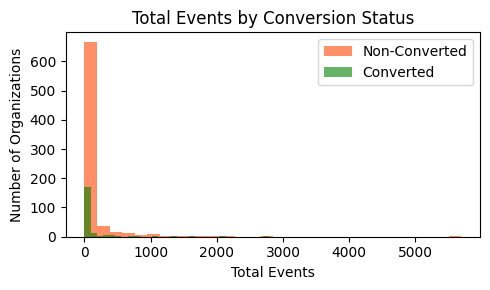

,count,mean,std,min,25%,50%,75%,max
CONVERTED,,,,,,,,
False,760.0,106.147368,343.626466,1.0,2.0,8.0,41.25,5691.0
True,206.0,107.878641,319.31732,1.0,2.0,8.0,49.0,2794.0


In [39]:
plt.figure(figsize=(5, 3))

# Plot histogram for Non-Converted organizations
plt.hist(
    df_organization[df_organization['CONVERTED'] == False]['total_events'],
    bins=30,
    color='orangered',
    alpha=0.6,  # transparency allows overlap visibility
    label='Non-Converted'
)

# Plot histogram for Converted organizations
plt.hist(
    df_organization[df_organization['CONVERTED'] == True]['total_events'],
    bins=30,
    color='green',
    alpha=0.6,
    label='Converted'
)

# Add labels and title
plt.title('Total Events by Conversion Status')
plt.xlabel('Total Events')
plt.ylabel('Number of Organizations')

plt.legend()  # show group labels

plt.tight_layout()  # adjust spacing
plt.show()


# Summary statistics of total_events by conversion status
df_organization.groupby('CONVERTED')['total_events'].describe()

### **`unique_activity_count`** by Conversion Status

#### Outcome:
- Median unique activities explored is the same for converters and non-converters.
- Some non-converters explored many features without converting, highlighting that **activity quality matters more than quantity**.
- Focus should be on the **number of unique activities that actually drive conversion**, not just total usage.

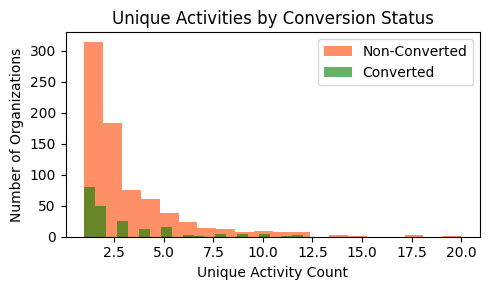

,count,mean,std,min,25%,50%,75%,max
CONVERTED,,,,,,,,
False,760.0,2.777632,2.648842,1.0,1.0,2.0,3.0,20.0
True,206.0,2.776699,2.429221,1.0,1.0,2.0,3.0,12.0


In [40]:
plt.figure(figsize=(5, 3))

# Histogram for Non-Converted organizations
plt.hist(
    df_organization[df_organization['CONVERTED'] == False]['unique_activity_count'],
    bins=20,  # slightly fewer bins often suits smaller count ranges
    color='orangered',
    alpha=0.6,  # transparency allows overlap visibility
    label='Non-Converted'
)

# Histogram for Converted organizations
plt.hist(
    df_organization[df_organization['CONVERTED'] == True]['unique_activity_count'],
    bins=20,
    color='green',
    alpha=0.6,
    label='Converted'
)

# Add labels and title
plt.title('Unique Activities by Conversion Status')
plt.xlabel('Unique Activity Count')
plt.ylabel('Number of Organizations')

plt.legend()  # show group labels

plt.tight_layout()
plt.show()


# Summary statistics by conversion group
df_organization.groupby('CONVERTED')['unique_activity_count'].describe()

### **`active_days`** by Conversion Status

#### Outcome:
- `active_days` **does not seem to differentiate converted vs non-converted organisations**.
- Most organisations, regardless of conversion, are active only **1–3 days**.
- The **long tail (up to 31 days)** is similar for both groups, so the extreme values don’t separate the groups either.

#### Validation check:
- The maximum value of 31 active days is expected despite a 30-day trial
- Activity counting starts on Day 1 (0 days from trial start)
- So activity recorded up to Day 31 represents full usage across the 30-day trial window

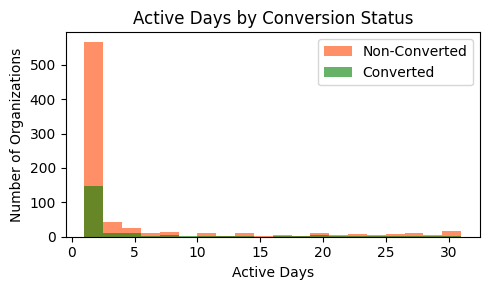

,count,mean,std,min,25%,50%,75%,max
CONVERTED,,,,,,,,
False,760.0,4.289474,7.317594,1.0,1.0,1.0,3.0,31.0
True,206.0,4.208738,6.799578,1.0,1.0,1.0,3.0,31.0


In [41]:
plt.figure(figsize=(5, 3))

# Histogram for Non-Converted organizations
plt.hist(
    df_organization[df_organization['CONVERTED'] == False]['active_days'],
    bins=20,
    color='orangered',
    alpha=0.6,  # transparency improves visibility of overlap
    label='Non-Converted'
)

# Histogram for Converted organizations
plt.hist(
    df_organization[df_organization['CONVERTED'] == True]['active_days'],
    bins=20,
    color='green',
    alpha=0.6,
    label='Converted'
)

# Add title and axis labels
plt.title('Active Days by Conversion Status')
plt.xlabel('Active Days')
plt.ylabel('Number of Organizations')

plt.legend()  # show group labels

plt.tight_layout()
plt.show()


# Summary statistics for comparison
df_organization.groupby('CONVERTED')['active_days'].describe()

### Activity Usage Breadth:
- Analyses **Number of Organisations** that **used Activity** (Feature) **at least once**.

In [42]:
# Merge conversion status into activity pivot
df_activity_with_conversion = df_activity_pivot_flag.merge(
    df_organization[['ORGANIZATION_ID', 'CONVERTED']],
    on='ORGANIZATION_ID',
    how='left'
)

# Total number of organizations
total_orgs = df_activity_with_conversion['ORGANIZATION_ID'].nunique()

# Separate converted and non-converted groups
converted_df = df_activity_with_conversion[
    df_activity_with_conversion['CONVERTED'] == True
]

not_converted_df = df_activity_with_conversion[
    df_activity_with_conversion['CONVERTED'] == False
]

# Get list of activity columns
activity_columns = df_activity_pivot_flag.columns.drop('ORGANIZATION_ID')

# Build summary table
activity_summary = pd.DataFrame({
    'ACTIVITY_NAME': activity_columns
})

# Total users per activity
activity_summary['USERS_COUNT'] = (
    df_activity_with_conversion[activity_columns].sum().values
)

# Percent of total users
activity_summary['COMPLETION_RATE_%'] = (
    activity_summary['USERS_COUNT'] / total_orgs * 100
).round(1)

# Converted users per activity
activity_summary['USERS_CONVERTED'] = (
    converted_df[activity_columns].sum().values
)

# # Non-converted users per activity
# activity_summary['USERS_NOT_CONVERTED'] = (
#     not_converted_df[activity_columns].sum().values
# )

# % Converted after usage
activity_summary['CONVERSION_RATE_AFTER_USAGE_%'] = (
    activity_summary['USERS_CONVERTED'] /
    activity_summary['USERS_COUNT'] * 100
).round(1)

# Sort by total usage (most used first)
activity_summary = activity_summary.sort_values(
    by='USERS_COUNT',
    ascending=False
)

activity_summary.reset_index(drop=True, inplace=True)

activity_summary

,ACTIVITY_NAME,USERS_COUNT,COMPLETION_RATE_%,USERS_CONVERTED,CONVERSION_RATE_AFTER_USAGE_%
0,Scheduling.Shift.Created,848,87.8,185,21.8
1,Mobile.Schedule.Loaded,456,47.2,97,21.3
2,Scheduling.Shift.AssignmentChanged,343,35.5,74,21.6
3,PunchClock.PunchedIn,211,21.8,48,22.7
4,Scheduling.Shift.Approved,200,20.7,44,22.0
5,Communication.Message.Created,145,15.0,24,16.6
6,Scheduling.Template.ApplyModal.Applied,108,11.2,27,25.0
7,Scheduling.Availability.Set,59,6.1,13,22.0
8,ShiftDetails.View.Opened,45,4.7,9,20.0
9,Scheduling.OpenShiftRequest.Created,43,4.5,13,30.2


### Activity Usage Depth (Volume):
- Counts **Number of times Activity** (Feature) was **used**.

In [43]:
# Sum all activity columns except ORGANIZATION_ID
activity_totals_df = (
    df_activity_pivot_count

    # Drop the ID column
    .drop(columns='ORGANIZATION_ID')

    # Sum all numeric columns
    .sum()

    # Convert Series to DataFrame
    .reset_index()

    # Rename columns
    .rename(columns={
        'index': 'ACTIVITY_NAME',
        0: 'TOTAL_USAGE'
    })
)

# Sort from most used to least used
activity_totals_df = activity_totals_df.sort_values(
    by='TOTAL_USAGE',
    ascending=False
).reset_index(drop=True)

# Preview
activity_totals_df.head(10)

,ACTIVITY_NAME,TOTAL_USAGE
0,Mobile.Schedule.Loaded,49540
1,Scheduling.Shift.Created,31818
2,Scheduling.Shift.AssignmentChanged,7608
3,PunchClock.PunchedIn,4833
4,Scheduling.Shift.Approved,2550
5,Communication.Message.Created,1576
6,ShiftDetails.View.Opened,1433
7,Scheduling.Availability.Set,1084
8,Scheduling.Template.ApplyModal.Applied,468
9,Absence.Request.Created,388


## Data Exports
- DataFrames to be used for **`Conversion Driver Analysis`**

In [47]:
# df_activity_pivot_flag
df_activity_pivot_flag.to_csv(
    "C:/Users/HP PC/Documents/jacob_dbt_projects/trial_activation_analysis/dataset/exports/df_activity_pivot_flag.csv",
    index=False
)

# df_organization
df_organization.to_csv(
    "C:/Users/HP PC/Documents/jacob_dbt_projects/trial_activation_analysis/dataset/exports/df_organization.csv",
    index=False
)

# df_organization_act_count
df_organization_act_count.to_csv(
    "C:/Users/HP PC/Documents/jacob_dbt_projects/trial_activation_analysis/dataset/exports/df_organization_act_count.csv",
    index=False
)

# df_organization_act_flag
df_organization_act_flag.to_csv(
    "C:/Users/HP PC/Documents/jacob_dbt_projects/trial_activation_analysis/dataset/exports/df_organization_act_flag.csv",
    index=False
)

# df_trial
df_trial.to_csv(
    "C:/Users/HP PC/Documents/jacob_dbt_projects/trial_activation_analysis/dataset/exports/df_trial.csv",
    index=False
)